In [ ]:
from google.colab import drive
from google.colab import data_table

drive.mount('/content/drive')
data_table.enable_dataframe_formatter()

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sns
import os
from os import path

In [ ]:
file_path = "/content/drive/MyDrive/Virtual Reality Lesson and Community Smells/Questionari/csv/"
file_name_1 = "Presenza_Normalizzato.csv"
file_name_2 = "Remoto_Normalizzato.csv"
file_name_3 = "VR_Normalizzato.csv"

df_presenza = pd.read_csv(file_path+file_name_1)
df_remoto = pd.read_csv(file_path+file_name_2)
df_vr = pd.read_csv(file_path+file_name_3)

In [ ]:
print(df_presenza.columns.names == df_remoto.columns.names)
print(df_vr.columns.names == df_remoto.columns.names)

df_presenza

True
True


,Cos'è il Social Debt?,Quale delle seguenti affermazioni descrive meglio un anti-pattern socio-tecnico?,Cosa sono i community smells?,Come differiscono i community smells dai code smells?,Qual è un esempio di community smell?,Quale affermazione sulla gestione del Social Debt è vera?,Qual è la principale differenza tra anti-pattern socio-tecnici e anti-pattern sociali,Cosa significa il termine 'Radio Silence' nel contesto dei community smells?,Vero o falso: Il Social Debt si riferisce solo ai costi finanziari di un progetto software.,Vero o falso: Gli anti-pattern socio-tecnici possono portare all'accumulo di Social Debt.,...,Ero distratt* e non ho seguito la lezione.,Durante la lezione ho lasciato che la mia mente vagasse.,Ho fatto finta di seguire la lezione.,Quanta attività mentale e percettiva ritieni sia stata richiesta durante la lezione? (Molto Semplice Da Seguire - Molto Impegnativa Da Seguire),Quanto è stata impegnativa fisicamente l’esperienza di seguire la lezione? (Molto Rilassante - Molto Faticosa),Come hai percepito il ritmo della lezione? Era lento o veloce? Sei riuscito/a a seguire l’esposizione dei concetti? (Nessuna Pressione - Molta Pressione),Valuta il tuo grado di soddisfazione riguardo alle tue prestazioni nell’ascoltare e comprendere la lezione (Massima Comprensione - Nessuna Comprensione),Quanto ti sei dovuto/a impegnare per mantenere un elevato livello di attenzione e comprensione durante la lezione? (Nessuno Sforzo - Massimo Sforzo),"Durante la lezione, come è variato il tuo livello di irritazione, stress e fastidio rispetto a quello di contentezza, relax e soddisfazione? (Massimo Relax - Massima Frustrazione)","Su una scala da 0 a 10, quante probabilità ci sono che parlerai positivamente di questa lezione sui 'Community Smells' a un amico o collega?"
0,1,1,1,1,1,1,1,1,1,1,...,0.000000,0.000000,0.000000,0.888889,1.000000,1.000000,1.000000,0.777778,1.000000,1.0
1,1,1,1,1,1,1,1,1,1,1,...,0.000000,0.000000,0.000000,0.777778,1.000000,0.666667,0.222222,0.666667,0.888889,0.8
2,1,1,1,1,1,1,1,1,0,1,...,0.166667,0.333333,0.000000,0.888889,0.888889,1.000000,0.888889,0.777778,1.000000,0.8
3,1,1,1,1,1,1,1,0,0,1,...,0.000000,0.000000,0.000000,0.888889,1.000000,1.000000,1.000000,0.888889,1.000000,0.8
4,0,1,1,1,1,1,1,1,1,1,...,0.000000,0.000000,0.000000,0.888889,1.000000,0.777778,0.888889,1.000000,0.888889,1.0
5,1,1,1,1,1,1,1,1,1,0,...,0.166667,0.166667,0.000000,0.888889,0.888889,1.000000,0.888889,0.888889,1.000000,1.0
6,1,1,1,1,1,1,1,1,1,1,...,0.166667,0.166667,0.166667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.9
7,1,1,1,1,1,1,1,1,1,1,...,0.000000,0.166667,0.000000,0.555556,0.666667,0.666667,0.777778,0.777778,0.777778,0.7
8,1,1,1,1,1,1,1,1,1,1,...,0.000000,0.166667,0.000000,0.444444,0.888889,0.555556,0.888889,0.444444,0.888889,0.8
9,1,1,1,1,1,1,1,1,1,1,...,0.500000,0.666667,0.166667,0.555556,0.666667,0.666667,0.777778,0.444444,0.555556,0.8


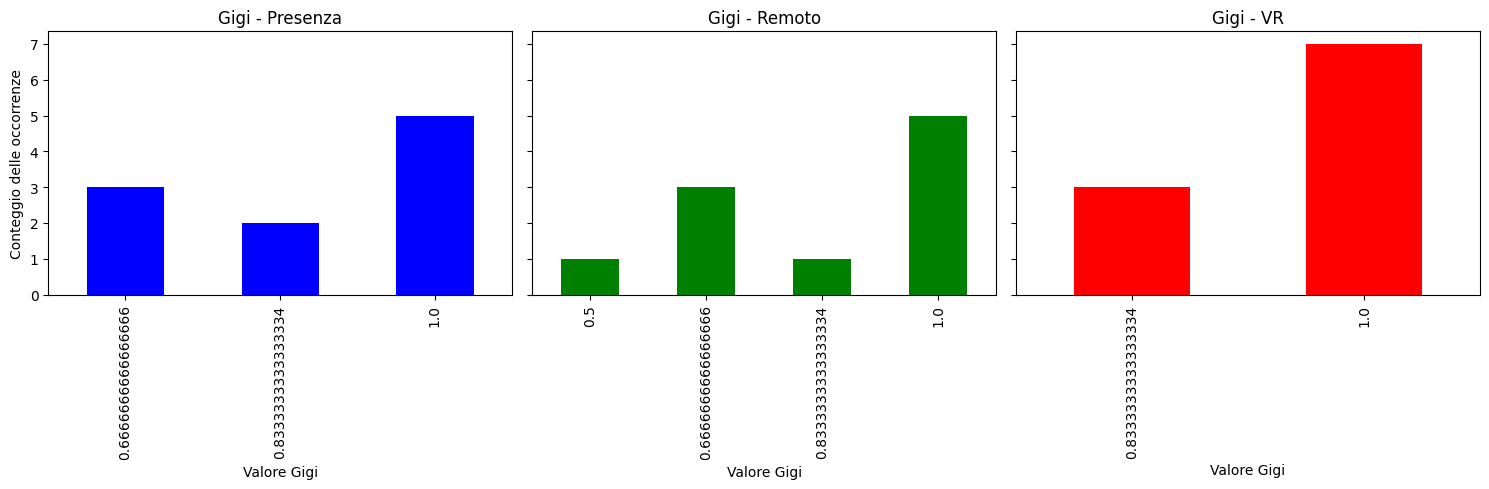

In [ ]:
column_name = "Partecipando alla lezione, mi sono sentit* intrattenut* (ho sorriso, ho riso, mi sono divertit*)."
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)

# Plottare i dati per ciascun DataFrame
df_presenza[column_name].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Gigi - Presenza', color='b')
df_remoto[column_name].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Gigi - Remoto', color='g')
df_vr[column_name].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Gigi - VR', color='r')

# Impostare etichette asse comune
for ax in axes:
    ax.set_xlabel('Valore Gigi')
    ax.set_ylabel('Conteggio delle occorrenze')

plt.tight_layout()
plt.show()

In [ ]:
variabili = {
    "Learning Outcome": list(range(0, 13)),
    "Self Efficacy": list(range(13, 23)),
    "Immersiveness": list(range(23, 33)),
    "Affective Engagement": list(range(33, 38)),
    "Behavioral Engagement": list(range(38, 44)),
    "Cognitivie Engagement": list(range(44, 46)),
    "Disengagement": list(range(46, 49)),
    "NASA-TLX": list(range(49, 55)),
    "NPS": [55]
}

df_presenza.iloc[:, variabili["NASA-TLX"]]


,Quanta attività mentale e percettiva ritieni sia stata richiesta durante la lezione? (Molto Semplice Da Seguire - Molto Impegnativa Da Seguire),Quanto è stata impegnativa fisicamente l’esperienza di seguire la lezione? (Molto Rilassante - Molto Faticosa),Come hai percepito il ritmo della lezione? Era lento o veloce? Sei riuscito/a a seguire l’esposizione dei concetti? (Nessuna Pressione - Molta Pressione),Valuta il tuo grado di soddisfazione riguardo alle tue prestazioni nell’ascoltare e comprendere la lezione (Massima Comprensione - Nessuna Comprensione),Quanto ti sei dovuto/a impegnare per mantenere un elevato livello di attenzione e comprensione durante la lezione? (Nessuno Sforzo - Massimo Sforzo),"Durante la lezione, come è variato il tuo livello di irritazione, stress e fastidio rispetto a quello di contentezza, relax e soddisfazione? (Massimo Relax - Massima Frustrazione)"
0,0.888889,1.000000,1.000000,1.000000,0.777778,1.000000
1,0.777778,1.000000,0.666667,0.222222,0.666667,0.888889
2,0.888889,0.888889,1.000000,0.888889,0.777778,1.000000
3,0.888889,1.000000,1.000000,1.000000,0.888889,1.000000
4,0.888889,1.000000,0.777778,0.888889,1.000000,0.888889
5,0.888889,0.888889,1.000000,0.888889,0.888889,1.000000
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,0.555556,0.666667,0.666667,0.777778,0.777778,0.777778
8,0.444444,0.888889,0.555556,0.888889,0.444444,0.888889
9,0.555556,0.666667,0.666667,0.777778,0.444444,0.555556


## Test di Mann-Whitney U su Affective Engagement

In [ ]:
df_presenza_engagement = df_presenza.iloc[:, variabili["Affective Engagement"]]
df_remoto_engagement = df_remoto.iloc[:, variabili["Affective Engagement"]]
df_vr_engagement = df_vr.iloc[:, variabili["Affective Engagement"]]

df_presenza_engagement

,Sono stat* interessat* alla lezione.,Sono stat* orgoglios* di partecipare alla lezione.,Sono stat* entusiasta di partecipare alla lezione.,Sono stat* felice di partecipare alla lezione.,"Partecipando alla lezione, mi sono sentit* intrattenut* (ho sorriso, ho riso, mi sono divertit*)."
0,1.000000,0.833333,0.833333,0.833333,1.000000
1,0.666667,0.166667,0.666667,0.833333,0.666667
2,1.000000,0.833333,0.833333,0.833333,1.000000
3,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.833333,0.833333,0.833333,0.833333,0.833333
5,1.000000,0.833333,1.000000,1.000000,1.000000
6,0.833333,0.666667,0.500000,0.500000,0.833333
7,0.666667,0.500000,0.666667,0.666667,0.666667
8,1.000000,0.833333,0.833333,0.833333,0.666667
9,0.833333,0.500000,0.666667,0.833333,1.000000


In [ ]:
df_presenza_engagement_mean = pd.DataFrame(df_presenza_engagement.mean(axis=1), columns=['Mean'])
df_remoto_engagement_mean = pd.DataFrame(df_remoto_engagement.mean(axis=1), columns=['Mean'])
df_vr_engagement_mean = pd.DataFrame(df_vr_engagement.mean(axis=1), columns=['Mean'])

df_vr_engagement_mean

,Mean
0,0.966667
1,0.966667
2,0.866667
3,1.000000
4,0.933333
5,1.000000
6,0.900000
7,1.000000
8,0.966667
9,1.000000


In [ ]:
presenza_values = df_presenza_engagement_mean.iloc[:, 0]
remoto_values = df_remoto_engagement_mean.iloc[:, 0]
vr_values = df_vr_engagement_mean.iloc[:, 0]

stat_presenza_remoto, p_presenza_remoto = mannwhitneyu(presenza_values, remoto_values)

stat_presenza_vr, p_presenza_vr = mannwhitneyu(presenza_values, vr_values)

stat_remoto_vr, p_remoto_vr = mannwhitneyu(remoto_values, vr_values)


print(f"Presenza vs Remoto: Stat={stat_presenza_remoto}, p-value={p_presenza_remoto}")
print(f"Presenza vs VR: Stat={stat_presenza_vr}, p-value={p_presenza_vr}")
print(f"Remoto vs VR: Stat={stat_remoto_vr}, p-value={p_remoto_vr}")

NameError: name 'mannwhitneyu' is not defined

## Test di Mann-Whitney U su Affective Engagement

In [ ]:
df_presenza_learning = df_presenza.iloc[:, variabili["Learning Outcome"]]
df_remoto_learning = df_remoto.iloc[:, variabili["Learning Outcome"]]
df_vr_learning = df_vr.iloc[:, variabili["Learning Outcome"]]

df_presenza_learning

In [ ]:
df_presenza_learning_mean = pd.DataFrame(df_presenza_learning.mean(axis=1), columns=['Mean'])
df_remoto_learning_mean = pd.DataFrame(df_remoto_learning.mean(axis=1), columns=['Mean'])
df_vr_learning_mean = pd.DataFrame(df_vr_learning.mean(axis=1), columns=['Mean'])

df_presenza_learning_mean

In [ ]:
presenza_values = df_presenza_learning_mean.iloc[:, 0]
remoto_values = df_remoto_learning_mean.iloc[:, 0]
vr_values = df_vr_learning_mean.iloc[:, 0]

stat_presenza_remoto, p_presenza_remoto = mannwhitneyu(presenza_values, remoto_values)

stat_presenza_vr, p_presenza_vr = mannwhitneyu(presenza_values, vr_values)

stat_remoto_vr, p_remoto_vr = mannwhitneyu(remoto_values, vr_values)


print(f"Presenza vs Remoto: Stat={stat_presenza_remoto}, p-value={p_presenza_remoto}")
print(f"Presenza vs VR: Stat={stat_presenza_vr}, p-value={p_presenza_vr}")
print(f"Remoto vs VR: Stat={stat_remoto_vr}, p-value={p_remoto_vr}")

## Test di Mann-Whitney U su Immersiveness

In [ ]:
df_presenza_immersiveness = df_presenza.iloc[:, variabili["Immersiveness"]]
df_remoto_immersiveness = df_remoto.iloc[:, variabili["Immersiveness"]]
df_vr_immersiveness = df_vr.iloc[:, variabili["Immersiveness"]]


df_presenza_immersiveness.to_csv("presenza_immersiveness.csv")
df_remoto_immersiveness.to_csv("remoto_immersiveness.csv")
df_vr_immersiveness.to_csv("vr_immersiveness.csv")

df_presenza_immersiveness

In [ ]:
!pip install factor_analyzer

In [ ]:
from factor_analyzer import FactorAnalyzer

df_concatenato = pd.concat([df_presenza_immersiveness, df_remoto_immersiveness, df_vr_immersiveness], axis=0)

fa = FactorAnalyzer(n_factors=9, rotation='varimax')
fa.fit(df_presenza_immersiveness)

# Estrarre i punteggi dei fattori
factor_loadings = fa.loadings_
print(factor_loadings)

In [ ]:
df_presenza_immersiveness_mean = pd.DataFrame(df_presenza_immersiveness.median(axis=1), columns=['Mean'])
df_remoto_immersiveness_mean = pd.DataFrame(df_remoto_immersiveness.median(axis=1), columns=['Mean'])
df_vr_immersiveness_mean = pd.DataFrame(df_vr_immersiveness.median(axis=1), columns=['Mean'])

df_presenza_immersiveness_mean

In [ ]:
presenza_values = df_presenza_immersiveness_mean.iloc[:, 0]
remoto_values = df_remoto_immersiveness_mean.iloc[:, 0]
vr_values = df_vr_immersiveness_mean.iloc[:, 0]

stat_presenza_remoto, p_presenza_remoto = mannwhitneyu(presenza_values, remoto_values)

stat_presenza_vr, p_presenza_vr = mannwhitneyu(presenza_values, vr_values)

stat_remoto_vr, p_remoto_vr = mannwhitneyu(remoto_values, vr_values)


print(f"Presenza vs Remoto: Stat={stat_presenza_remoto}, p-value={p_presenza_remoto}")
print(f"Presenza vs VR: Stat={stat_presenza_vr}, p-value={p_presenza_vr}")
print(f"Remoto vs VR: Stat={stat_remoto_vr}, p-value={p_remoto_vr}")

## Test di Mann-Whitney U su Self Efficacy

In [ ]:
df_presenza_efficacy = df_presenza.iloc[:, variabili["Self Efficacy"]]
df_remoto_efficacy = df_remoto.iloc[:, variabili["Self Efficacy"]]
df_vr_efficacy = df_vr.iloc[:, variabili["Self Efficacy"]]

df_presenza_efficacy

In [ ]:
df_presenza_efficacy_mean = pd.DataFrame(df_presenza_efficacy.median(axis=1), columns=['Mean'])
df_remoto_efficacy_mean = pd.DataFrame(df_remoto_efficacy.median(axis=1), columns=['Mean'])
df_vr_efficacy_mean = pd.DataFrame(df_vr_efficacy.median(axis=1), columns=['Mean'])

df_presenza_efficacy_mean

In [ ]:
presenza_values = df_presenza_efficacy_mean.iloc[:, 0]
remoto_values = df_remoto_efficacy_mean.iloc[:, 0]
vr_values = df_vr_efficacy_mean.iloc[:, 0]

stat_presenza_remoto, p_presenza_remoto = mannwhitneyu(presenza_values, remoto_values)

stat_presenza_vr, p_presenza_vr = mannwhitneyu(presenza_values, vr_values)

stat_remoto_vr, p_remoto_vr = mannwhitneyu(remoto_values, vr_values)


print(f"Presenza vs Remoto: Stat={stat_presenza_remoto}, p-value={p_presenza_remoto}")
print(f"Presenza vs VR: Stat={stat_presenza_vr}, p-value={p_presenza_vr}")
print(f"Remoto vs VR: Stat={stat_remoto_vr}, p-value={p_remoto_vr}")